In [3]:
pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 2.3 MB/s  0:00:19m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 3.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.4 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [albumentations]m [opencv-python-headless]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-macos 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [13]:
## This code works for Mac M4 Chip

import os
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    ToTensorV2() 
])

class UrbanHabitatDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)
        
        with rasterio.open(img_path) as src_img:
            image = src_img.read()
            image = np.transpose(image, (1, 2, 0)) 
            
        with rasterio.open(mask_path) as src_mask:
            mask = src_mask.read(1)
            
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = mask.to(torch.long)
            
        return image, mask

img_dir = "data/model_ready/images"
mask_dir = "data/model_ready/masks"

train_dataset = UrbanHabitatDataset(img_dir, mask_dir, transform=train_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

print(f"Dataset initialized with {len(train_dataset)} tiles.")
print(f"DataLoader created with {len(train_loader)} batches.")

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Metal Performance Shaders (MPS) detected! The M4 Max is ready to train.")
else:
    device = torch.device("cpu")
    print("MPS not detected. Running on CPU.")

Dataset initialized with 100 tiles.
DataLoader created with 25 batches.
Apple Metal Performance Shaders (MPS) detected! The M4 Max is ready to train.


Image batch shape: torch.Size([4, 3, 1000, 1000]) (Batch, Channels, Height, Width)
Mask batch shape: torch.Size([4, 1000, 1000]) (Batch, Height, Width)


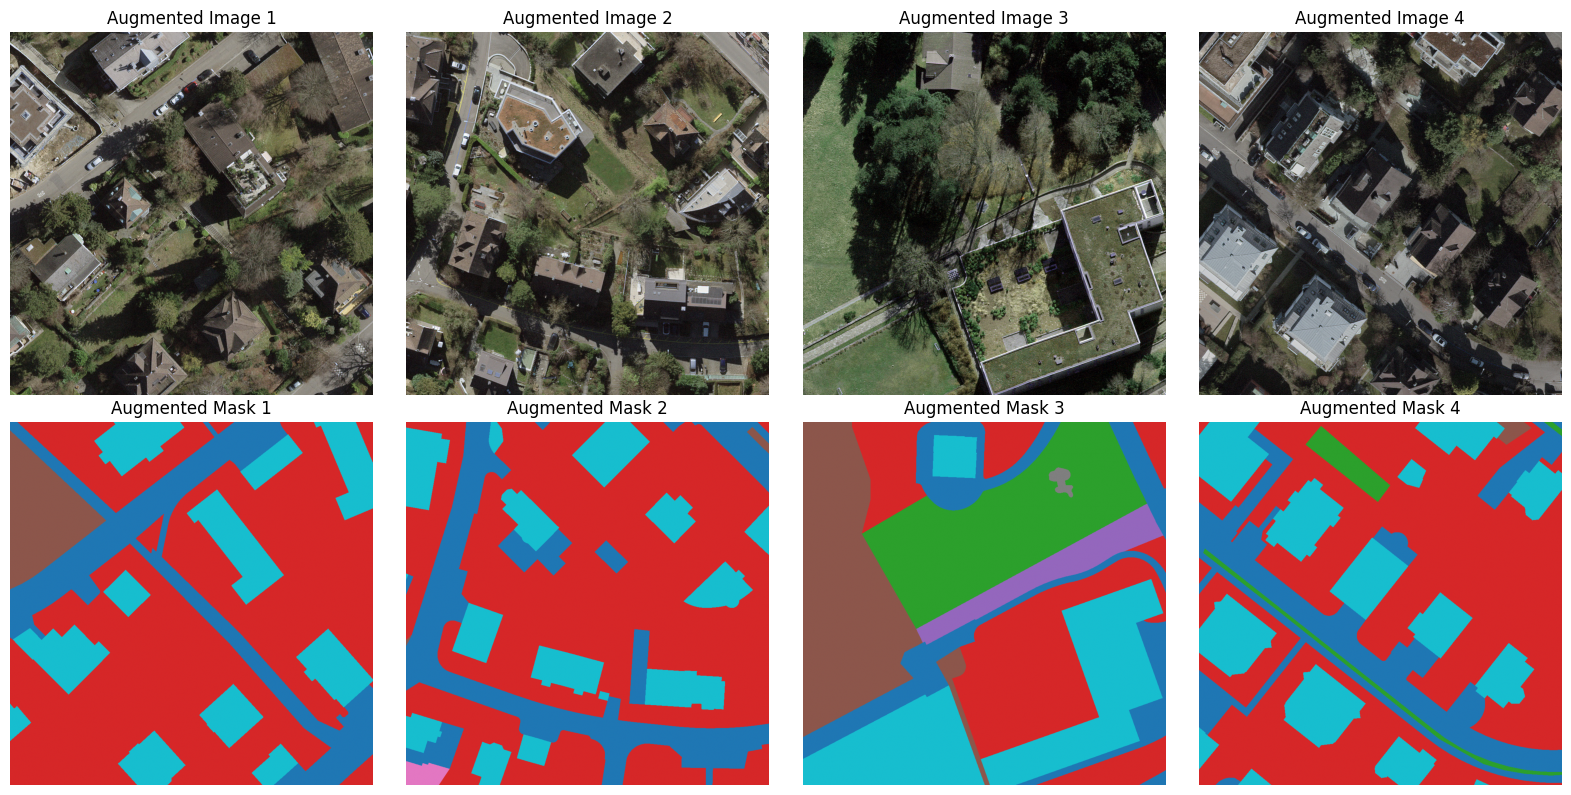

In [14]:
images, masks = next(iter(train_loader))

print(f"Image batch shape: {images.shape} (Batch, Channels, Height, Width)")
print(f"Mask batch shape: {masks.shape} (Batch, Height, Width)")

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img = images[i].numpy().transpose(1, 2, 0)
    mask = masks[i].numpy()
    
    # Plot Image
    axs[0, i].imshow(img)
    axs[0, i].set_title(f"Augmented Image {i+1}")
    axs[0, i].axis('off')
    
    # Plot Mask
    axs[1, i].imshow(mask, cmap='tab10', vmin=0, vmax=9)
    axs[1, i].set_title(f"Augmented Mask {i+1}")
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 498.8 kB/s  0:00:20eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 2.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.5 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 3.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [transformers] [transformers]
Note: you may need to restart the kernel to use updated packages.


In [15]:
from transformers import SegformerForSemanticSegmentation

id2label = {
    0: 'Impervious / Built-up',
    1: 'Forest & Dense Canopy',
    2: 'Urban Trees & Bushes',
    3: 'Managed Green Spaces',
    4: 'Standard Grassland',
    5: 'Ecologically Valuable Meadow',
    6: 'Agriculture & Orchards',
    7: 'Water Bodies'
}
label2id = {v: k for k, v in id2label.items()}

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model = model.to(device)

print(f"SegFormer initialized and moved to: {device}")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

SegFormer initialized and moved to: mps


In [18]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

# 1. Setup Optimizer 
optimizer = optim.AdamW(model.parameters(), lr=0.00006)

loss_fn = nn.CrossEntropyLoss(ignore_index=255)

model.train()
epochs = 5 

print(f"Starting training on {device} for {epochs} epochs...")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    running_loss = 0.0
    
    for images, masks in tqdm(train_loader, desc="Training Batches"):
        
        # Prepare the data
        images = (images.float() / 255.0).to(device)
        masks = masks.to(device, dtype=torch.long)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(pixel_values=images)
        logits = outputs.logits
        
        masks_4d = masks.unsqueeze(1).float()
        masks_resized = F.interpolate(masks_4d, size=logits.shape[-2:], mode="nearest")
        masks_resized = masks_resized.squeeze(1).long()
        
        loss = loss_fn(logits, masks_resized)
        
        loss.backward()
        
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Average Training Loss: {avg_loss:.4f}")

print("\n🎉 Training Prototype Complete!")

Starting training on mps for 5 epochs...

Epoch 1/5


Training Batches:   0%|                                  | 0/25 [00:01<?, ?it/s]


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.